# Pendulum DDPG

## 实验目标

本实验使用 `DDPG` 训练 `Pendulum-v1` 的连续动作控制策略。目标是让摆杆稳定接近竖直位置，同时降低角速度和控制代价。这里的重点不仅是把训练跑起来，还要把确定性策略梯度方法在连续动作任务中的价值讲清楚。

## 为什么这里选择 DDPG

`Pendulum-v1` 是经典的连续动作控制环境，很适合用 `DDPG`，原因很直接：

- 动作空间连续，不能再用离散动作枚举
- 控制输出需要细粒度调节力矩
- 任务奖励同时受姿态误差、角速度和动作幅度影响
- 环境规模适中，适合展示 actor-critic 在连续控制中的基本逻辑

因此，这里使用 `DDPG`，是为了把连续动作强化学习从离散值函数方法自然过渡到策略输出方法。

## 收敛判断方式

这个 notebook 不会笼统地说“已经学会”，而是通过几组具体信号判断训练是否进入稳定阶段：

- episode return 是否持续改善
- 最近回合平均回报是否明显优于随机基线
- 固定评估阶段的平均回报是否进入稳定区间
- 评估阶段的平均角误差和平均角速度是否持续下降
- 策略可视化中是否出现连贯、平滑的力矩输出区域

只有这些信号同时成立，才说明 `DDPG` 不是偶然把摆杆拉上去几次，而是真的学到了连续反馈控制。

## 设备与并行说明

- 本实验固定使用 `CPU`
- 不使用 `CUDA` 或 `MPS`
- 不引入并行环境

这类经典 `DDPG` 实验的关键不在多进程采样，而在经验回放、动作噪声和训练预算是否足够稳定。

In [1]:
from pathlib import Path

import gymnasium as gym
import imageio.v2 as imageio
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from stable_baselines3 import DDPG
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.noise import NormalActionNoise

In [2]:
ENV_ID = "Pendulum-v1"
TOTAL_TIMESTEPS = 120000
LEARNING_RATE = 1e-3
BUFFER_SIZE = 200000
LEARNING_STARTS = 5000
BATCH_SIZE = 256
GAMMA = 0.98
TAU = 0.005
TRAIN_FREQ = 1
GRADIENT_STEPS = 1
ACTION_NOISE_SIGMA = 0.1
EVAL_EPISODES = 100
ROLLOUT_EPISODES = 3
ROLLOUT_FPS = 30
MAX_STEPS = 200
QUALITY_THRESHOLD_RETURN = -300
SEED = 42
DEVICE = "cpu"

RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(exist_ok=True)

## 参数选择说明

这里的参数选择明显向“更容易收敛”倾斜，而不是追求和前面实验完全对称：

- `TOTAL_TIMESTEPS = 120000`：给 Pendulum 充分训练预算
- `BUFFER_SIZE = 200000`：扩大经验回放容量，降低样本相关性
- `LEARNING_STARTS = 5000`：让回放池先积累一定多样性
- `ACTION_NOISE_SIGMA = 0.1`：保留适度探索，避免动作过早收缩
- `GAMMA = 0.98`：在姿态控制与长期稳定之间取得平衡

如果评估回报仍不稳定，优先调整方向通常是继续增加训练步数、适度降低噪声强度，或调节网络宽度与批量大小。

In [3]:
class EpisodeStatsCallback(BaseCallback):
    def __init__(self):
        super().__init__()
        self.episode_returns = []
        self.episode_lengths = []
        self.quality_flags = []

    def _on_step(self) -> bool:
        infos = self.locals.get("infos", [])
        for info in infos:
            if "episode" in info:
                episode_return = float(info["episode"]["r"])
                episode_length = int(info["episode"]["l"])
                self.episode_returns.append(episode_return)
                self.episode_lengths.append(episode_length)
                self.quality_flags.append(int(episode_return >= QUALITY_THRESHOLD_RETURN))
        return True

In [4]:
train_env = Monitor(gym.make(ENV_ID))
action_noise = NormalActionNoise(mean=np.zeros(1), sigma=ACTION_NOISE_SIGMA * np.ones(1))
callback = EpisodeStatsCallback()

model = DDPG(
    policy="MlpPolicy",
    env=train_env,
    learning_rate=LEARNING_RATE,
    buffer_size=BUFFER_SIZE,
    learning_starts=LEARNING_STARTS,
    batch_size=BATCH_SIZE,
    gamma=GAMMA,
    tau=TAU,
    train_freq=TRAIN_FREQ,
    gradient_steps=GRADIENT_STEPS,
    action_noise=action_noise,
    policy_kwargs=dict(net_arch=[256, 256]),
    verbose=0,
    device=DEVICE,
    seed=SEED,
)

model.learn(total_timesteps=TOTAL_TIMESTEPS, callback=callback, progress_bar=True)
train_env.close()

Output()

In [5]:
episode_return_series = pd.Series(callback.episode_returns, dtype=float)
episode_length_series = pd.Series(callback.episode_lengths, dtype=float)
quality_series = pd.Series(callback.quality_flags, dtype=float)
rolling_return = episode_return_series.rolling(50).mean() if len(episode_return_series) >= 50 else episode_return_series
rolling_length = episode_length_series.rolling(50).mean() if len(episode_length_series) >= 50 else episode_length_series
rolling_quality = quality_series.rolling(50).mean() if len(quality_series) >= 50 else quality_series

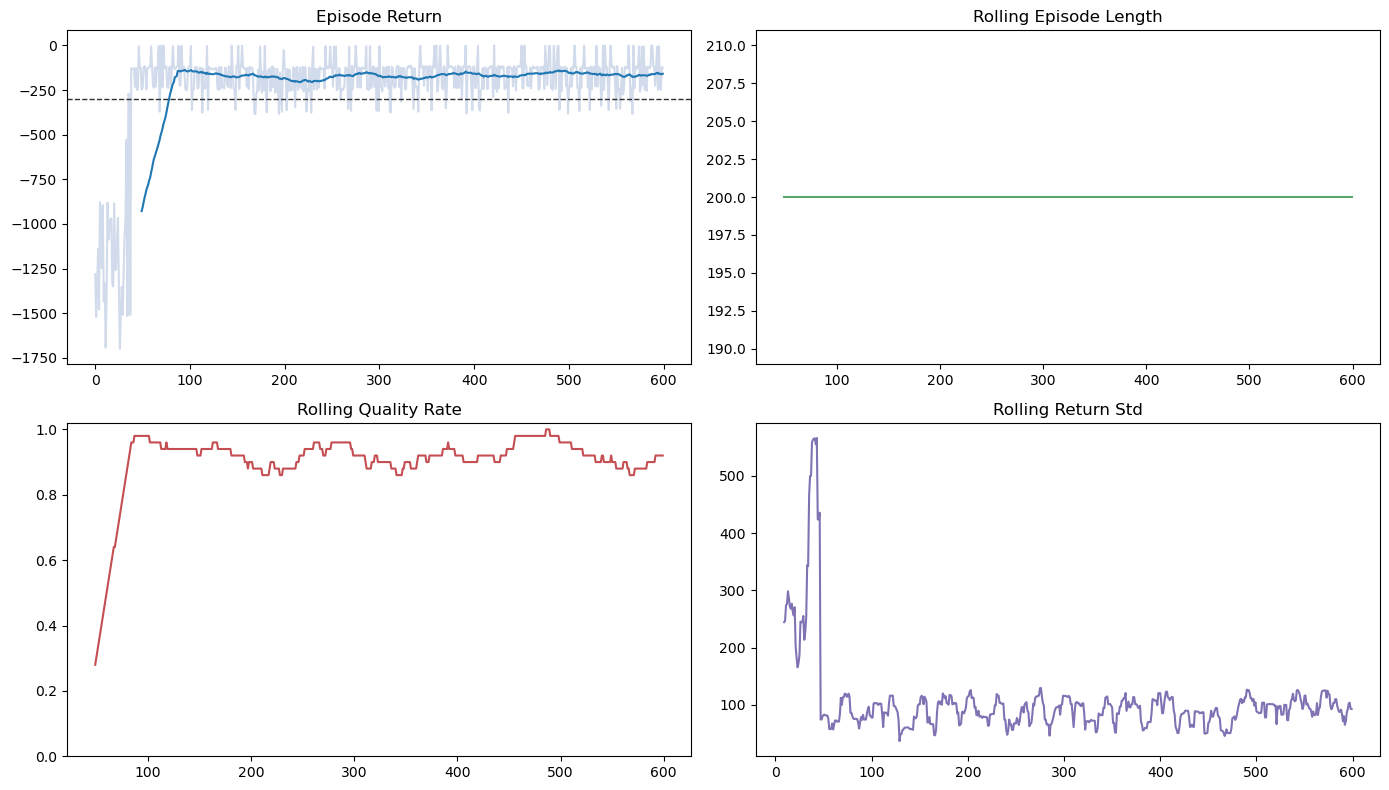

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0, 0].plot(callback.episode_returns, alpha=0.25, color="#4c72b0")
axes[0, 0].plot(rolling_return, color="#1f77b4")
axes[0, 0].axhline(QUALITY_THRESHOLD_RETURN, linestyle="--", color="#2f2f2f", linewidth=1)
axes[0, 0].set_title("Episode Return")

axes[0, 1].plot(rolling_length, color="#55a868")
axes[0, 1].set_title("Rolling Episode Length")

axes[1, 0].plot(rolling_quality, color="#c44e52")
axes[1, 0].set_title("Rolling Quality Rate")
axes[1, 0].set_ylim(0, 1.02)

axes[1, 1].plot(pd.Series(callback.episode_returns).rolling(10).std(), color="#8172b3")
axes[1, 1].set_title("Rolling Return Std")

plt.tight_layout()
plt.savefig(RESULTS_DIR / "ddpg_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

In [7]:
eval_returns = []
eval_angle_errors = []
eval_mean_abs_angular_velocities = []
eval_quality_flags = []

for episode in range(EVAL_EPISODES):
    eval_env = gym.make(ENV_ID)
    obs, info = eval_env.reset(seed=SEED + 10000 + episode)
    total_reward = 0.0
    angular_velocities = []
    for step in range(MAX_STEPS):
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = eval_env.step(action)
        total_reward += reward
        angular_velocities.append(abs(float(obs[2])))
        if terminated or truncated:
            break
    theta = float(np.arctan2(obs[1], obs[0]))
    angle_error = float(abs(((theta + np.pi) % (2 * np.pi)) - np.pi))
    eval_returns.append(total_reward)
    eval_angle_errors.append(angle_error)
    eval_mean_abs_angular_velocities.append(float(np.mean(angular_velocities)))
    eval_quality_flags.append(int(total_reward >= QUALITY_THRESHOLD_RETURN))
    eval_env.close()

eval_results = pd.DataFrame({
    "evaluation_return": eval_returns,
    "final_angle_error": eval_angle_errors,
    "mean_abs_angular_velocity": eval_mean_abs_angular_velocities,
    "quality_flag": eval_quality_flags,
})
eval_results.head()

,evaluation_return,final_angle_error,mean_abs_angular_velocity,quality_flag
0,-125.603323,0.10959,0.535996,1
1,-117.858807,0.10959,0.463420,1
2,-127.102056,0.10959,0.570840,1
3,-122.102581,0.10959,0.519136,1
4,-2.355229,0.10959,0.015482,1


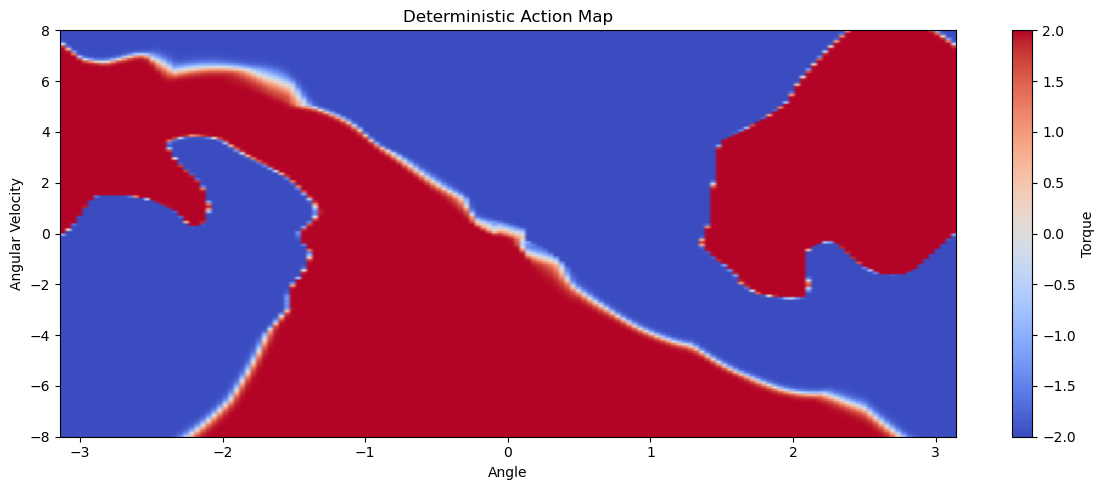

In [8]:
angle_values = np.linspace(-np.pi, np.pi, 160)
velocity_values = np.linspace(-8, 8, 160)
action_grid = np.zeros((len(velocity_values), len(angle_values)))

for i, angular_velocity in enumerate(velocity_values):
    for j, angle in enumerate(angle_values):
        obs = np.array([np.cos(angle), np.sin(angle), angular_velocity], dtype=np.float32)
        action, _ = model.predict(obs, deterministic=True)
        action_grid[i, j] = float(action[0])

plt.figure(figsize=(12, 5))
plt.imshow(action_grid, extent=[angle_values[0], angle_values[-1], velocity_values[0], velocity_values[-1]], origin="lower", aspect="auto", cmap="coolwarm")
plt.colorbar(label="Torque")
plt.title("Deterministic Action Map")
plt.xlabel("Angle")
plt.ylabel("Angular Velocity")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "ddpg_policy_visualization.png", dpi=150, bbox_inches="tight")
plt.show()

In [9]:
rollout_summaries = []
for rollout_idx in range(ROLLOUT_EPISODES):
    rollout_env = gym.make(ENV_ID, render_mode="rgb_array")
    obs, info = rollout_env.reset(seed=SEED + 20000 + rollout_idx)
    frames = []
    total_reward = 0.0
    angular_velocities = []

    for step in range(MAX_STEPS):
        frame = rollout_env.render()
        if frame is not None:
            frames.append(frame)
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = rollout_env.step(action)
        total_reward += reward
        angular_velocities.append(abs(float(obs[2])))
        if terminated or truncated:
            break

    theta = float(np.arctan2(obs[1], obs[0]))
    angle_error = float(abs(((theta + np.pi) % (2 * np.pi)) - np.pi))
    final_frame = rollout_env.render()
    if final_frame is not None:
        frames.extend([final_frame] * 20)
    rollout_summaries.append({
        "rollout_index": rollout_idx + 1,
        "seed": SEED + 20000 + rollout_idx,
        "total_reward": float(total_reward),
        "final_angle_error": angle_error,
        "mean_abs_angular_velocity": float(np.mean(angular_velocities)),
        "quality_flag": int(total_reward >= QUALITY_THRESHOLD_RETURN),
    })
    if frames:
        imageio.mimsave(RESULTS_DIR / f"ddpg_rollout_{rollout_idx + 1}.gif", frames, fps=ROLLOUT_FPS)
    rollout_env.close()

pd.DataFrame(rollout_summaries)

,rollout_index,seed,total_reward,final_angle_error,mean_abs_angular_velocity,quality_flag
0,1,20042,-119.433597,0.10959,0.472420,1
1,2,20043,-129.978578,0.10959,0.592476,1
2,3,20044,-3.637391,0.10959,0.039633,1


In [10]:
metrics = pd.DataFrame({
    "metric": [
        "device",
        "total_timesteps",
        "recent_episode_return_last_50",
        "recent_episode_length_last_50",
        "recent_quality_rate_last_50",
        "evaluation_average_return",
        "evaluation_return_std",
        "evaluation_quality_rate",
        "evaluation_average_final_angle_error",
        "evaluation_average_mean_abs_angular_velocity",
    ],
    "value": [
        DEVICE,
        TOTAL_TIMESTEPS,
        float(episode_return_series.tail(50).mean()) if len(episode_return_series) > 0 else 0.0,
        float(episode_length_series.tail(50).mean()) if len(episode_length_series) > 0 else 0.0,
        float(quality_series.tail(50).mean()) if len(quality_series) > 0 else 0.0,
        float(np.mean(eval_returns)),
        float(np.std(eval_returns)),
        float(np.mean(eval_quality_flags)),
        float(np.mean(eval_angle_errors)),
        float(np.mean(eval_mean_abs_angular_velocities)),
    ],
})
metrics

,metric,value
0,device,cpu
1,total_timesteps,120000
2,recent_episode_return_last_50,-158.453321
3,recent_episode_length_last_50,200.0
4,recent_quality_rate_last_50,0.92
5,evaluation_average_return,-118.301952
6,evaluation_return_std,70.606657
7,evaluation_quality_rate,0.99
8,evaluation_average_final_angle_error,0.10959
9,evaluation_average_mean_abs_angular_velocity,0.445674


In [11]:
episode_summary = pd.DataFrame({
    "episode_return": callback.episode_returns,
    "episode_length": callback.episode_lengths,
    "quality_flag": callback.quality_flags,
})

episode_summary.to_csv(RESULTS_DIR / "ddpg_episode_summary.csv", index=False)
eval_results.to_csv(RESULTS_DIR / "ddpg_eval_results.csv", index=False)
metrics.to_csv(RESULTS_DIR / "ddpg_metrics.csv", index=False)
pd.DataFrame(rollout_summaries).to_csv(RESULTS_DIR / "ddpg_rollout_summary.csv", index=False)
print(metrics.to_string(index=False))

                                      metric       value
                                      device         cpu
                             total_timesteps      120000
               recent_episode_return_last_50 -158.453321
               recent_episode_length_last_50       200.0
                 recent_quality_rate_last_50        0.92
                   evaluation_average_return -118.301952
                       evaluation_return_std   70.606657
                     evaluation_quality_rate        0.99
        evaluation_average_final_angle_error     0.10959
evaluation_average_mean_abs_angular_velocity    0.445674


## 结果解读

如果评估平均回报明显优于随机基线，平均角误差和平均角速度明显下降，并且回放中能看到力矩连续、平滑地把摆杆拉向竖直位置，就说明 `DDPG` 已经学会了 Pendulum 的基本连续控制逻辑。